Set Up

In [1]:
import sys
assert sys.version_info >= (3, 5)

import warnings
warnings.filterwarnings('ignore')

import sklearn
assert sklearn.__version__ >= "0.20"

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math

np.random.seed(21)

In [2]:
df = pd.read_csv('../data_csv/zillow_clean.csv')

In [17]:
df.columns

Index(['price', 'bed', 'bath', 'living', 'lot_sqft', 'lot_living', 'bed_bath',
       'type_condo', 'type_manufactured', 'type_multi', 'type_single',
       'type_townhouse', 'lat', 'long', 'income', 'poverty', 'unemployment',
       'pop', 'bachelor', 'rent', 'owner_occ', 'pop_density', 'risk_overall',
       'risk_loss', 'risk_social', 'risk_resilience', 'risk_fire',
       'risk_earthquake', 'risk_heat', 'dist_city', 'dist_airport',
       'dist_coast'],
      dtype='str')

In [3]:
df.head()

,price,bed,bath,living,lot_a,lot_living,bed_bath,type_condo,type_lot,type_manufactured,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,...,97.665680,97.421143,55.160220,12.692809,0.000000,99.403042,7.484866,1.711220,17.894899,21.449547
4,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,False,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372


In [4]:
df.dropna(subset=['price'], inplace=True)

In [5]:
df.head()

,price,bed,bath,living,lot_a,lot_living,bed_bath,type_condo,type_lot,type_manufactured,...,risk_overall,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,80.718966,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,75.714982,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,92.322785,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300
4,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,False,...,68.423055,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372
5,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,53.028195,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601


In [6]:
df = df.dropna(subset=["price"])
df = df[df["price"] != 0].copy()

In [7]:
#Bỏ những dòng là đất / không có thông tin nhà
df = df.dropna(
    subset=["bed", "bath", "living"],
    how="all"
)
# Bỏ dòng bed = 0, bath = 0, living = 0

bad_rows = (
    (df["bed"].fillna(0) == 0) &
    (df["bath"].fillna(0) == 0) &
    (df["living"].fillna(0) == 0)
)

df = df[~bad_rows].copy()

Handling missing values

,Total,Percent
rent,655,14.037720
lot_living,624,13.373339
income,541,11.594514
lot_a,539,11.551650
owner_occ,504,10.801543
unemployment,504,10.801543
bachelor,504,10.801543
poverty,504,10.801543
pop_density,503,10.780111
pop,503,10.780111


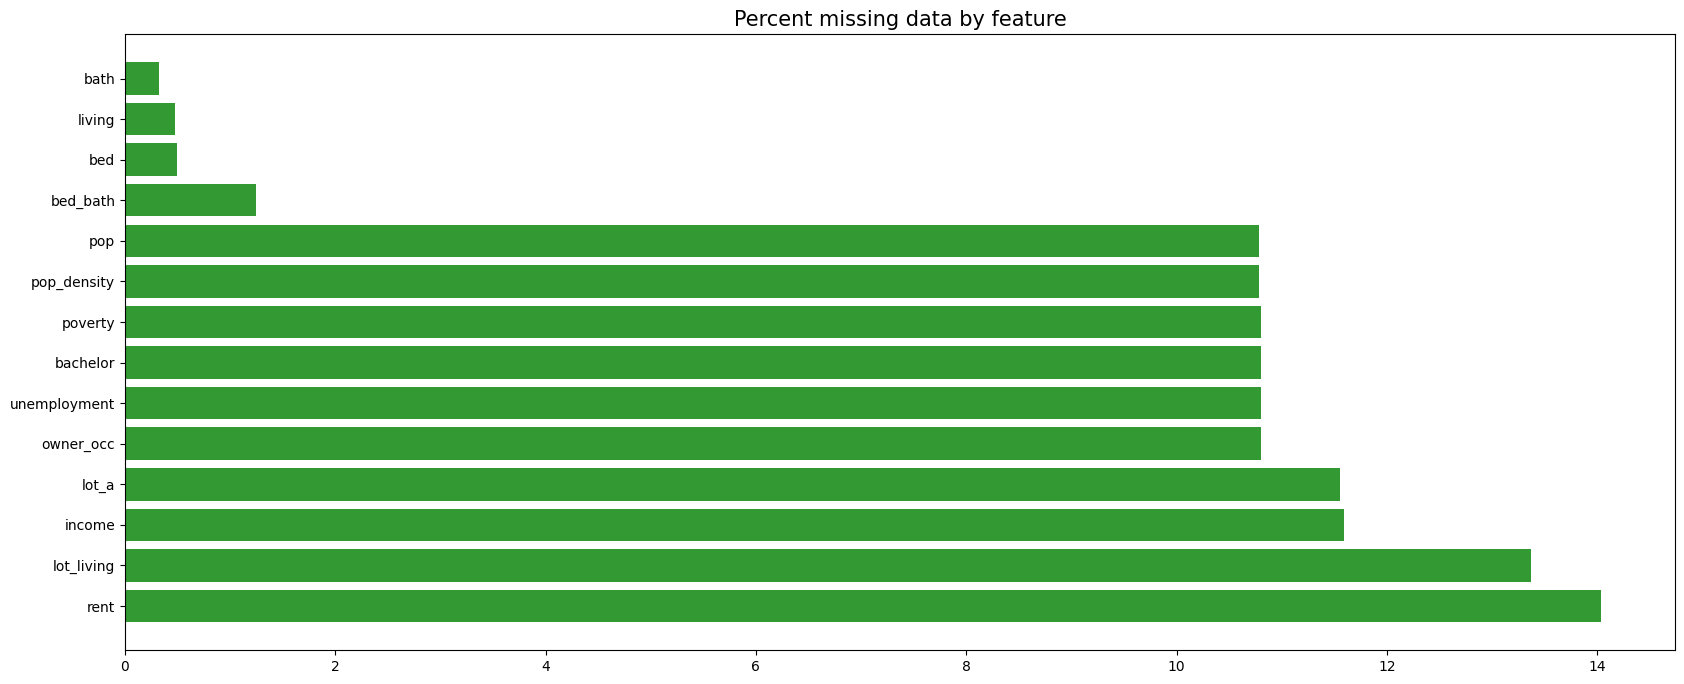

In [8]:
def missingData(data):
    total = data.isnull().sum().sort_values(ascending = False)
    percent = (data.isnull().sum()/data.isnull().count()*100).sort_values(ascending = False)
    md = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    md = md[md["Percent"] > 0]
    plt.figure(figsize = (20, 8))
    plt.barh(md.index, md["Percent"],color="g",alpha=0.8)
    plt.title('Percent missing data by feature', fontsize=15)
    return md
missingData(df)

Ta thấy bed , living , bath missing không quá nhiều -> Bỏ để mô hình ổn định , sạch


In [9]:
df = df.dropna(subset=["bed", "bath", "living"])
df = df[
    (df["bed"] > 0) &
    (df["bath"] > 0) &
    (df["living"] > 0)
].copy()

Còn những giá trị còn lại thì chúng ta sẽ dùng median ( lấy trung vị) để xử lý 

In [ ]:
median_cols = [
    "rent",
    "income",
    "lot_a",
    "unemployment",
    "owner_occ",
    "bachelor",
    "poverty",
    "pop",
    "pop_density",
    "bed",
    "bath",
    "living"
]
median_cols = [col for col in median_cols if col in df.columns]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())


df["bed_bath"] = df["bed"] / df["bath"].replace(0, np.nan)

df["lot_living"] = df["lot_a"] / df["living"].replace(0, np.nan)

# Nếu sau khi chia vẫn còn NaN thì fill median nốt
df["bed_bath"] = df["bed_bath"].fillna(df["bed_bath"].median())
df["lot_living"] = df["lot_living"].fillna(df["lot_living"].median())

df.rename(columns={"lot_a": "lot_sqft"}, inplace=True) #diện tích đất tính bằng square feet
df["lot_living"] = df["lot_sqft"] / df["living"]

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 4468 entries, 0 to 5751
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              4468 non-null   float64
 1   bed                4468 non-null   float64
 2   bath               4468 non-null   float64
 3   living             4468 non-null   float64
 4   lot_sqft           4468 non-null   float64
 5   lot_living         4468 non-null   float64
 6   bed_bath           4468 non-null   float64
 7   type_condo         4468 non-null   bool   
 8   type_lot           4468 non-null   bool   
 9   type_manufactured  4468 non-null   bool   
 10  type_multi         4468 non-null   bool   
 11  type_single        4468 non-null   bool   
 12  type_townhouse     4468 non-null   bool   
 13  lat                4468 non-null   float64
 14  long               4468 non-null   float64
 15  income             4468 non-null   float64
 16  poverty            4468 non-null   float

In [12]:
print(len(df[df["type_single"] == True]))

3254


In [13]:
print(
    df.nlargest(
        30,
        "lot_living"
    ))

          price   bed  bath  living      lot_sqft     lot_living  bed_bath  \
4349  7995000.0   4.0   4.0  5966.0  2.047320e+09  343164.599397  1.000000   
326    925000.0   3.0   3.0  1897.0  3.816292e+08  201175.097522  1.000000   
1705   899000.0   4.0   2.0  1789.0  2.657160e+08  148527.669089  2.000000   
5731   949900.0   4.0   2.0  2067.0  2.613600e+08  126444.121916  2.000000   
1052   567999.0   3.0   4.0  2205.0  2.086960e+08   94646.693878  0.750000   
3984  1500000.0   3.0   1.0  1088.0  1.002751e+08   92164.632353  3.000000   
3752   240000.0   1.0   1.0   589.0  1.202256e+07   20411.816638  1.000000   
5684  1495000.0   1.0   1.0   768.0  5.227200e+06    6806.250000  1.000000   
3952  2175000.0  11.0   4.0  5200.0  1.132560e+07    2178.000000  2.750000   
2747   215000.0   3.0   2.0  1104.0  1.445756e+06    1309.561957  1.500000   
1502   335000.0   4.0   2.0  1496.0  1.867853e+06    1248.564706  2.000000   
4431  5100000.0   1.0   1.0  1400.0  1.306800e+06     933.428571

In [14]:
print(df.isna().sum().sort_values(ascending=False).head(20))

print("Total missing:", df.isna().sum().sum())


price                0
bed                  0
bath                 0
living               0
lot_sqft             0
lot_living           0
bed_bath             0
type_condo           0
type_lot             0
type_manufactured    0
type_multi           0
type_single          0
type_townhouse       0
lat                  0
long                 0
income               0
poverty              0
unemployment         0
pop                  0
bachelor             0
dtype: int64
Total missing: 0


In [15]:
df = df.drop(columns=["type_lot"]) # Do không còn dòng nào

In [19]:
upper = df["price"].quantile(0.95)
df = df[df["price"] <= upper]

In [20]:
df.to_csv("../data_csv/zillow_final.csv", index=False, encoding="utf-8-sig")